In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import gaussian_kde

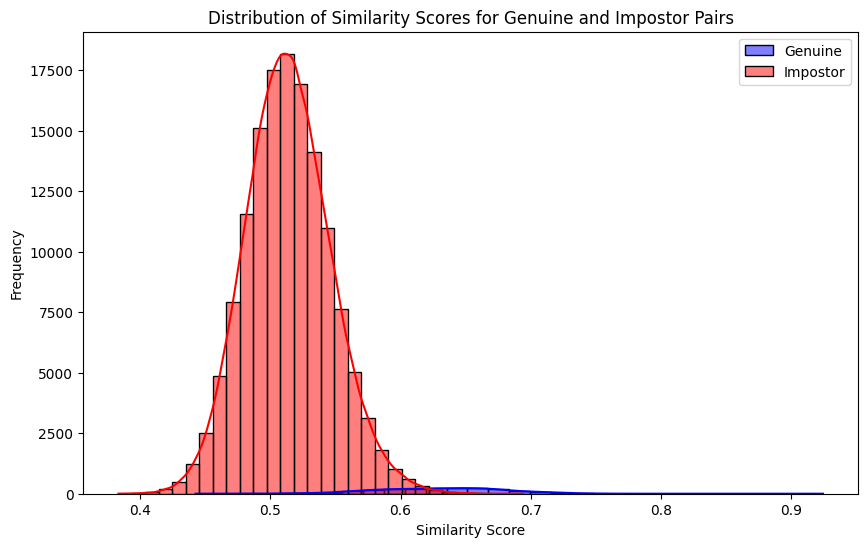

In [7]:
# Load your dataframe with the similarity scores
df_pairs_optimized = pd.read_csv('optimized_pairs_with_similarity.csv')  # Update this path if needed

# Split the data into genuine and impostor groups
genuine_scores = df_pairs_optimized[df_pairs_optimized['Genuine']]['AdaFace_Similarity']
impostor_scores = df_pairs_optimized[~df_pairs_optimized['Genuine']]['AdaFace_Similarity']

# Set up the plot
plt.figure(figsize=(10, 6))

# Plot genuine scores distribution
sns.histplot(genuine_scores, bins=30, kde=True, color='blue', alpha=0.5, label='Genuine')

# Plot impostor scores distribution
sns.histplot(impostor_scores, bins=30, kde=True, color='red', alpha=0.5, label='Impostor')

# Add labels and title
plt.xlabel('Similarity Score')
plt.ylabel('Frequency')
plt.title('Distribution of Similarity Scores for Genuine and Impostor Pairs')

# Add a legend
plt.legend()

# Show the plot
plt.show()

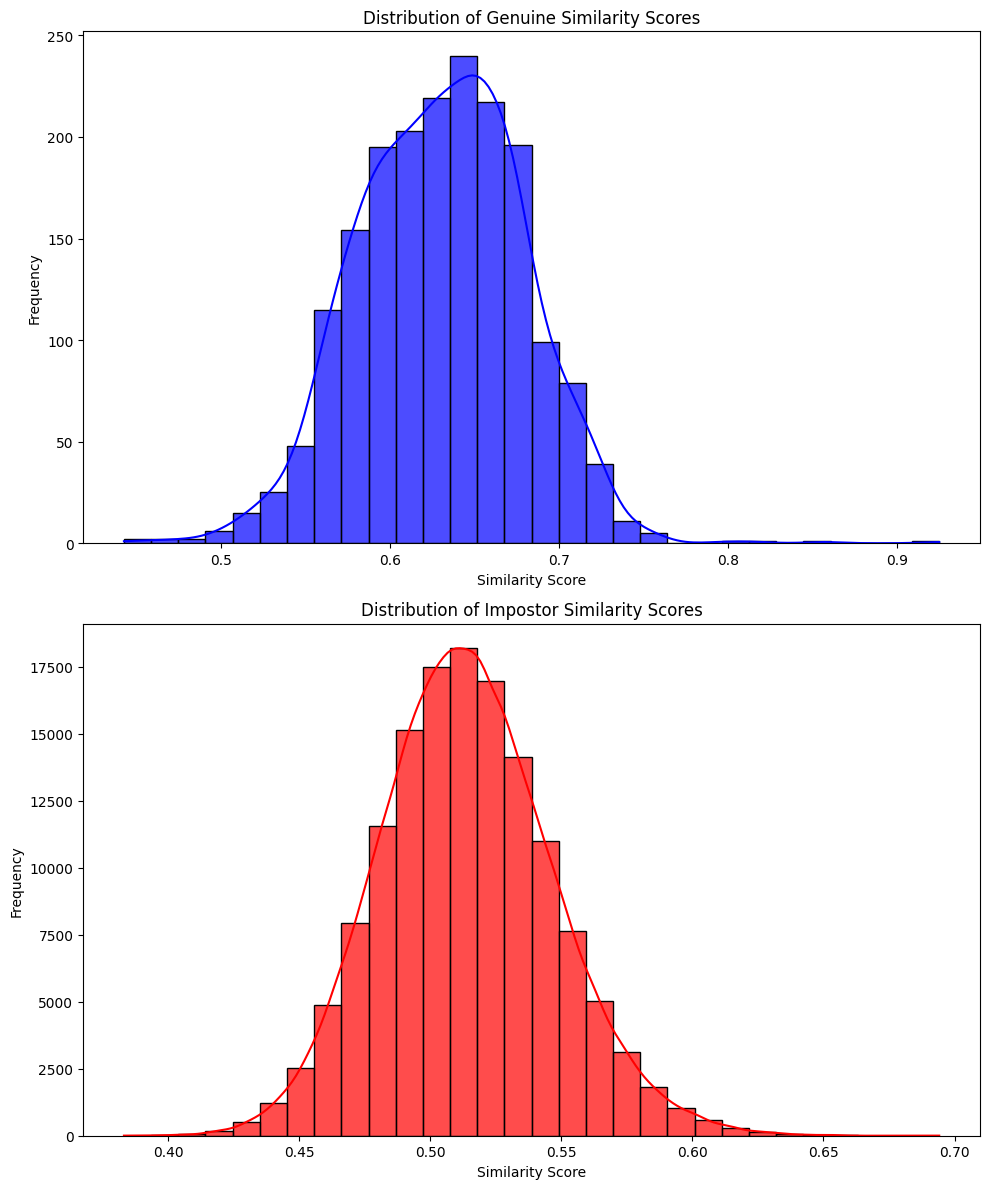

In [8]:
# Load your dataframe with the similarity scores
df_pairs_optimized = pd.read_csv('optimized_pairs_with_similarity.csv')  # Update this path if needed

# Split the data into genuine and impostor groups
genuine_scores = df_pairs_optimized[df_pairs_optimized['Genuine']]['AdaFace_Similarity']
impostor_scores = df_pairs_optimized[~df_pairs_optimized['Genuine']]['AdaFace_Similarity']

# Set up the figure and subplots
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 12))

# Plot genuine scores distribution
sns.histplot(genuine_scores, bins=30, kde=True, color='blue', alpha=0.7, ax=ax1)
ax1.set_title('Distribution of Genuine Similarity Scores')
ax1.set_xlabel('Similarity Score')
ax1.set_ylabel('Frequency')

# Plot impostor scores distribution
sns.histplot(impostor_scores, bins=30, kde=True, color='red', alpha=0.7, ax=ax2)
ax2.set_title('Distribution of Impostor Similarity Scores')
ax2.set_xlabel('Similarity Score')
ax2.set_ylabel('Frequency')

# Adjust layout to prevent overlap
plt.tight_layout()

# Show the plots
plt.show()

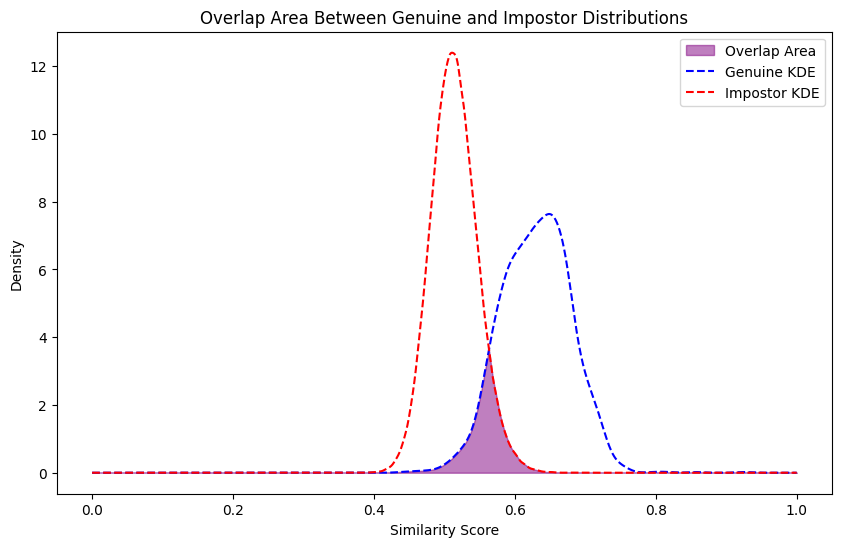

In [9]:
# Load your dataframe with the similarity scores
df_pairs_optimized = pd.read_csv('../optimized_pairs_with_similarity_deid.csv')  # Update this path if needed

# Split the data into genuine and impostor groups
genuine_scores = df_pairs_optimized[df_pairs_optimized['Genuine']]['AdaFace_Similarity']
impostor_scores = df_pairs_optimized[~df_pairs_optimized['Genuine']]['AdaFace_Similarity']

# Compute KDE for both distributions
genuine_kde = gaussian_kde(genuine_scores)
impostor_kde = gaussian_kde(impostor_scores)

# Define the range of x values (similarity scores)
x = np.linspace(0, 1, 1000)

# Evaluate the KDEs over the x values
genuine_density = genuine_kde(x)
impostor_density = impostor_kde(x)

# Find the minimum density between the two distributions at each point (overlap)
overlap_density = np.minimum(genuine_density, impostor_density)

# Plot the overlapping area
plt.figure(figsize=(10, 6))
plt.fill_between(x, overlap_density, color='purple', alpha=0.5, label='Overlap Area')
plt.plot(x, genuine_density, color='blue', linestyle='--', label='Genuine KDE')
plt.plot(x, impostor_density, color='red', linestyle='--', label='Impostor KDE')

# Add labels and title
plt.xlabel('Similarity Score')
plt.ylabel('Density')
plt.title('Overlap Area Between Genuine and Impostor Distributions')
plt.legend()

# Show the plot
plt.show()

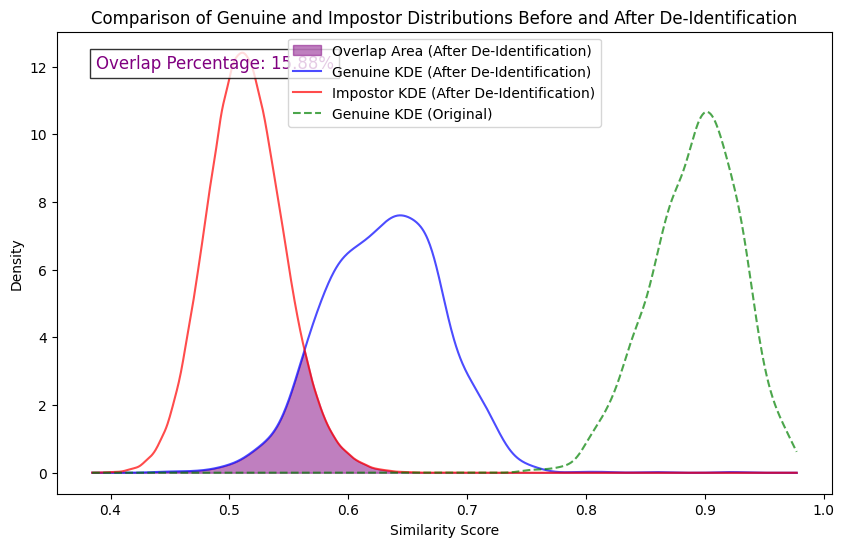

Percentage of Genuine Overlap with Impostors (After De-Identification): 15.88%


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

# Load your dataframes with the similarity scores
#df_pairs_optimized = pd.read_csv('../optimized_pairs_with_similarity_cpp_deid_0.5_masked.csv')
#df_pairs_optimized = pd.read_csv('../optimized_pairs_with_similarity_cpp_o_5_deid_no_mask.csv')
#df_pairs_original = pd.read_csv('../optimized_pairs_with_similarity_original.csv')
#df_pairs_optimized = pd.read_csv('../optimized_pairs_with_similarity_rafd-frontal-GDDPG_masked.csv')
df_pairs_optimized = pd.read_csv('../optimized_pairs_with_similarity_rafd-frontal-GDDPG.csv')
#df_pairs_original = pd.read_csv('../optimized_pairs_with_similarity_rafd-frontal_masked.csv')
df_pairs_original = pd.read_csv('../optimized_pairs_with_similarity_rafd-frontal.csv')

# Split the data into genuine and impostor groups for both datasets
genuine_scores_deid = df_pairs_optimized[df_pairs_optimized['Genuine']]['AdaFace_Similarity']
impostor_scores_deid = df_pairs_optimized[~df_pairs_optimized['Genuine']]['AdaFace_Similarity']
genuine_scores_original = df_pairs_original[df_pairs_original['Genuine']]['AdaFace_Similarity']

# Kernel density estimation (KDE) for all distributions
genuine_kde_deid = gaussian_kde(genuine_scores_deid)
impostor_kde_deid = gaussian_kde(impostor_scores_deid)
genuine_kde_original = gaussian_kde(genuine_scores_original)

# Create a range of x values covering all distributions
x_values = np.linspace(min(min(genuine_scores_deid), min(impostor_scores_deid), min(genuine_scores_original)),
                       max(max(genuine_scores_deid), max(impostor_scores_deid), max(genuine_scores_original)), 1000)

# Calculate the densities for all distributions
genuine_density_deid = genuine_kde_deid(x_values)
impostor_density_deid = impostor_kde_deid(x_values)
genuine_density_original = genuine_kde_original(x_values)

# Find the minimum of the densities for overlap (between genuine and impostor after de-identification)
overlap_density = np.minimum(genuine_density_deid, impostor_density_deid)

# Plot the distributions
plt.figure(figsize=(10, 6))
plt.fill_between(x_values, overlap_density, color='purple', alpha=0.5, label='Overlap Area (After De-Identification)')
plt.plot(x_values, genuine_density_deid, color='blue', label='Genuine KDE (After De-Identification)', alpha=0.7)
plt.plot(x_values, impostor_density_deid, color='red', label='Impostor KDE (After De-Identification)', alpha=0.7)
plt.plot(x_values, genuine_density_original, color='green', linestyle='--', label='Genuine KDE (Original)', alpha=0.7)

# Labels and title
plt.title('Comparison of Genuine and Impostor Distributions Before and After De-Identification')
plt.xlabel('Similarity Score')
plt.ylabel('Density')
plt.legend()

# Calculate the percentage overlap for the de-identified data
genuine_area_deid = np.trapz(genuine_density_deid, x_values)  # Area under the genuine curve after de-identification
overlap_area_deid = np.trapz(overlap_density, x_values)  # Area of the overlap after de-identification
percentage_overlap_deid = (overlap_area_deid / genuine_area_deid) * 100

# Add the overlap percentage to the plot
plt.text(0.05, 0.95, f'Overlap Percentage: {percentage_overlap_deid:.2f}%', 
         transform=plt.gca().transAxes, fontsize=12, color='purple', 
         verticalalignment='top', bbox=dict(facecolor='white', alpha=0.8))

# Show the plot
plt.show()

print(f"Percentage of Genuine Overlap with Impostors (After De-Identification): {percentage_overlap_deid:.2f}%")



Filtered out 35 rows from the optimized dataframe.
Filtered out 38 rows from the original dataframe.


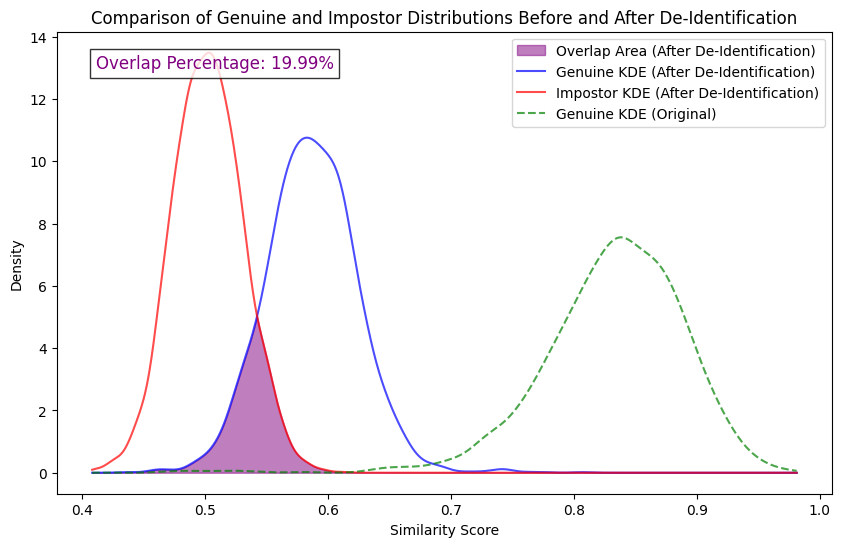

Percentage of Genuine Overlap with Impostors (After De-Identification): 19.99%


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

# Load your dataframes with the similarity scores
#df_pairs_optimized = pd.read_csv('../data_with_similarity_final_Mask_DDPG.csv') #baseline
df_pairs_optimized = pd.read_csv('../data_with_similarity_final_Mask_DDPG_LFW_benchmark_aligned_0_5_deid.csv')
df_pairs_original = pd.read_csv('../data_with_similarity_final_original.csv')

# Filter out rows with null or empty values in the 'Similarity' column and count them
initial_optimized_count = len(df_pairs_optimized)
initial_original_count = len(df_pairs_original)

df_pairs_optimized = df_pairs_optimized.dropna(subset=['Similarity'])
df_pairs_original = df_pairs_original.dropna(subset=['Similarity'])

filtered_optimized_count = initial_optimized_count - len(df_pairs_optimized)
filtered_original_count = initial_original_count - len(df_pairs_original)

print(f"Filtered out {filtered_optimized_count} rows from the optimized dataframe.")
print(f"Filtered out {filtered_original_count} rows from the original dataframe.")

# Split the data into genuine and impostor groups for both datasets
genuine_scores_deid = df_pairs_optimized[df_pairs_optimized['IsGenuine']]['Similarity']
impostor_scores_deid = df_pairs_optimized[~df_pairs_optimized['IsGenuine']]['Similarity']
genuine_scores_original = df_pairs_original[df_pairs_original['IsGenuine']]['Similarity']

# Kernel density estimation (KDE) for all distributions
genuine_kde_deid = gaussian_kde(genuine_scores_deid)
impostor_kde_deid = gaussian_kde(impostor_scores_deid)
genuine_kde_original = gaussian_kde(genuine_scores_original)

# Create a range of x values covering all distributions
x_values = np.linspace(min(min(genuine_scores_deid), min(impostor_scores_deid), min(genuine_scores_original)),
                       max(max(genuine_scores_deid), max(impostor_scores_deid), max(genuine_scores_original)), 1000)

# Calculate the densities for all distributions
genuine_density_deid = genuine_kde_deid(x_values)
impostor_density_deid = impostor_kde_deid(x_values)
genuine_density_original = genuine_kde_original(x_values)

# Find the minimum of the densities for overlap (between genuine and impostor after de-identification)
overlap_density = np.minimum(genuine_density_deid, impostor_density_deid)

# Plot the distributions
plt.figure(figsize=(10, 6))
plt.fill_between(x_values, overlap_density, color='purple', alpha=0.5, label='Overlap Area (After De-Identification)')
plt.plot(x_values, genuine_density_deid, color='blue', label='Genuine KDE (After De-Identification)', alpha=0.7)
plt.plot(x_values, impostor_density_deid, color='red', label='Impostor KDE (After De-Identification)', alpha=0.7)
plt.plot(x_values, genuine_density_original, color='green', linestyle='--', label='Genuine KDE (Original)', alpha=0.7)

# Labels and title
plt.title('Comparison of Genuine and Impostor Distributions Before and After De-Identification')
plt.xlabel('Similarity Score')
plt.ylabel('Density')
plt.legend()

# Calculate the percentage overlap for the de-identified data
genuine_area_deid = np.trapz(genuine_density_deid, x_values)  # Area under the genuine curve after de-identification
overlap_area_deid = np.trapz(overlap_density, x_values)  # Area of the overlap after de-identification
percentage_overlap_deid = (overlap_area_deid / genuine_area_deid) * 100

# Add the overlap percentage to the plot
plt.text(0.05, 0.95, f'Overlap Percentage: {percentage_overlap_deid:.2f}%', 
         transform=plt.gca().transAxes, fontsize=12, color='purple', 
         verticalalignment='top', bbox=dict(facecolor='white', alpha=0.8))

# Show the plot
plt.show()

print(f"Percentage of Genuine Overlap with Impostors (After De-Identification): {percentage_overlap_deid:.2f}%")


Filtered out 35 rows from the optimized dataframe.
Filtered out 38 rows from the original dataframe.


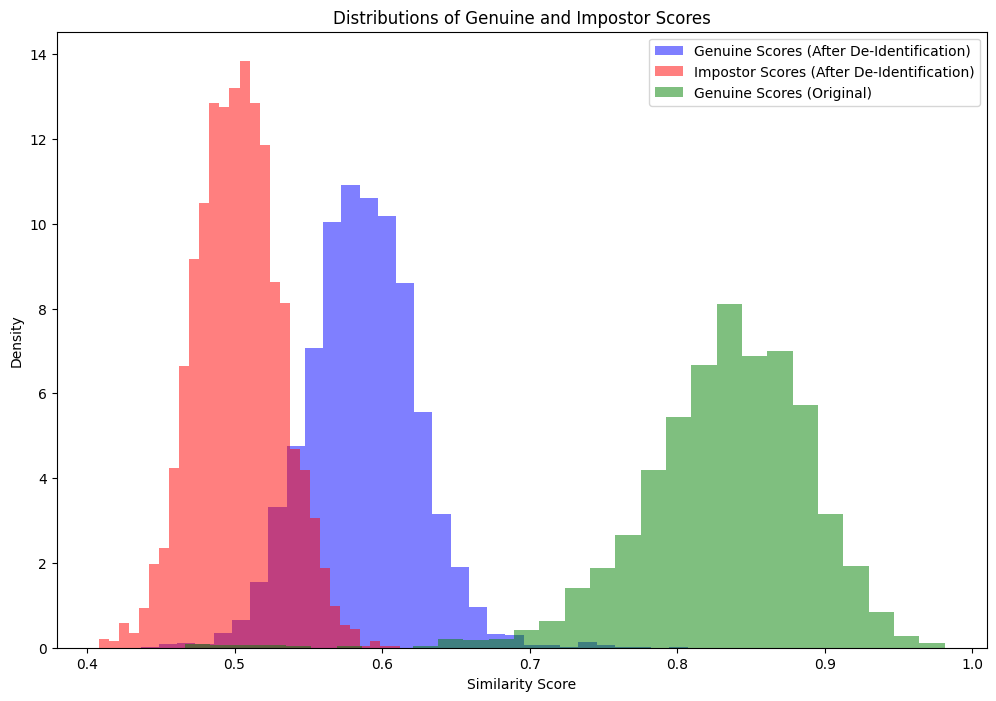

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load your dataframes with the similarity scores
#df_pairs_optimized = pd.read_csv('../data_with_similarity_final_Mask_DDPG.csv') #baseline
df_pairs_optimized = pd.read_csv('../data_with_similarity_final_Mask_DDPG_LFW_benchmark_aligned_0_5_deid.csv')
df_pairs_original = pd.read_csv('../data_with_similarity_final_original.csv')

# Filter out rows with null or empty values in the 'Similarity' column and count them
initial_optimized_count = len(df_pairs_optimized)
initial_original_count = len(df_pairs_original)

df_pairs_optimized = df_pairs_optimized.dropna(subset=['Similarity'])
df_pairs_original = df_pairs_original.dropna(subset=['Similarity'])

filtered_optimized_count = initial_optimized_count - len(df_pairs_optimized)
filtered_original_count = initial_original_count - len(df_pairs_original)

print(f"Filtered out {filtered_optimized_count} rows from the optimized dataframe.")
print(f"Filtered out {filtered_original_count} rows from the original dataframe.")

# Split the data into genuine and impostor groups for both datasets
genuine_scores_deid = df_pairs_optimized[df_pairs_optimized['IsGenuine']]['Similarity']
impostor_scores_deid = df_pairs_optimized[~df_pairs_optimized['IsGenuine']]['Similarity']
genuine_scores_original = df_pairs_original[df_pairs_original['IsGenuine']]['Similarity']

# Plot the distributions using histograms
plt.figure(figsize=(12, 8))

# Genuine scores after de-identification
plt.hist(genuine_scores_deid, bins=30, color='blue', alpha=0.5, label='Genuine Scores (After De-Identification)', density=True)

# Impostor scores after de-identification
plt.hist(impostor_scores_deid, bins=30, color='red', alpha=0.5, label='Impostor Scores (After De-Identification)', density=True)

# Genuine scores before de-identification
plt.hist(genuine_scores_original, bins=30, color='green', alpha=0.5, label='Genuine Scores (Original)', density=True)

# Labels and legend
plt.title('Distributions of Genuine and Impostor Scores')
plt.xlabel('Similarity Score')
plt.ylabel('Density')
plt.legend(loc='upper right')

# Show the plot
plt.show()


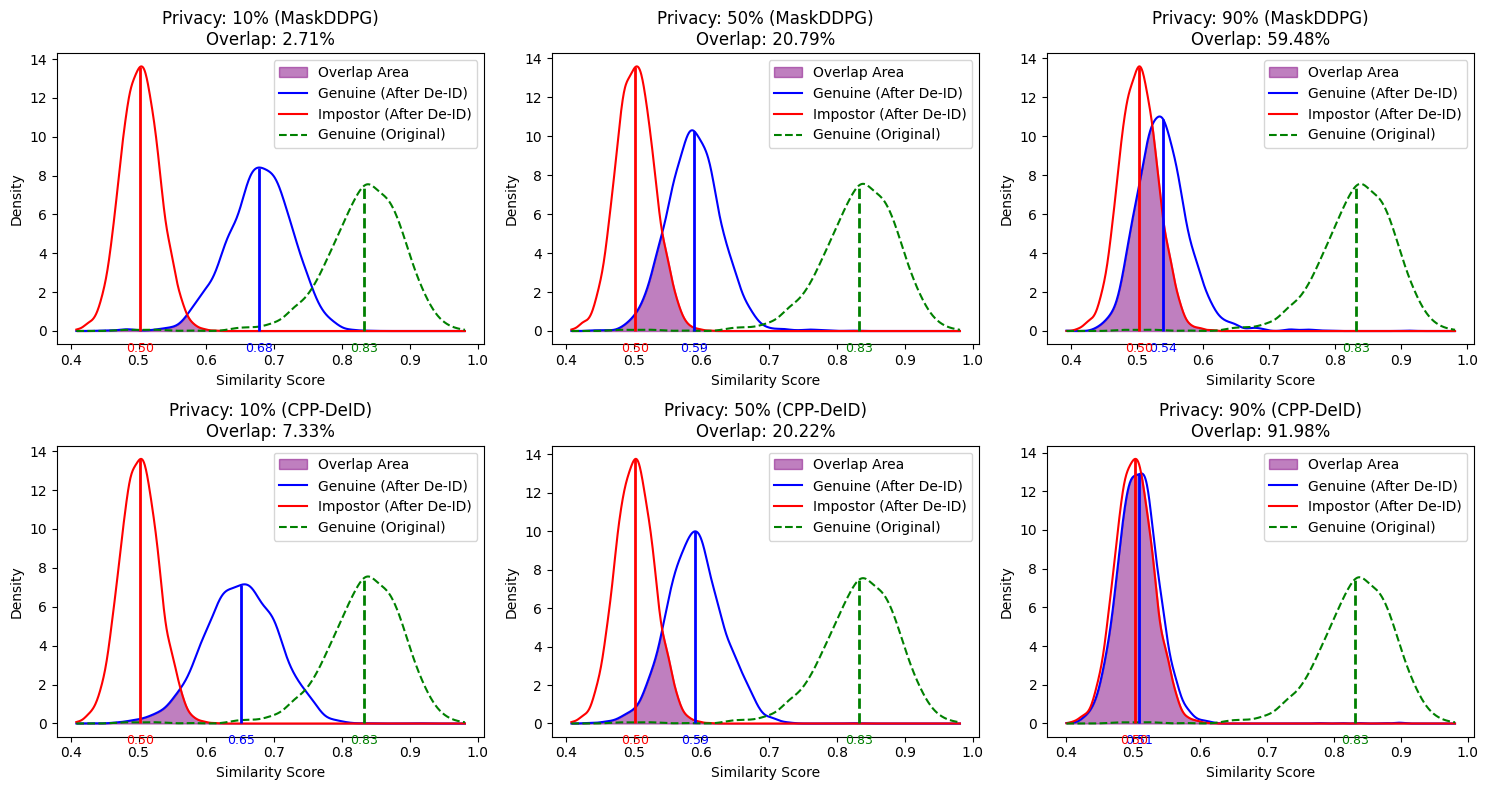

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

# List of CSV files to compare against the original
csv_files = [
    '../verification_scores_maskDDPG/LFW_benchmark_aligned_1_1_deid.csv',
    '../verification_scores_maskDDPG/LFW_benchmark_aligned_1_5_deid.csv',
    '../verification_scores_maskDDPG/LFW_benchmark_aligned_1_9_deid.csv',
    '../verification_scores_CPP/0.9.csv',
    '../verification_scores_CPP/0.5.csv',
    '../verification_scores_CPP/0.1.csv'
]
privacy_per_file_names = [
    'Privacy: 10% (MaskDDPG)',
    'Privacy: 50% (MaskDDPG)',
    'Privacy: 90% (MaskDDPG)',
    'Privacy: 10% (CPP-DeID)',
    'Privacy: 50% (CPP-DeID)',
    'Privacy: 90% (CPP-DeID)'
]
# Original dataset
df_pairs_original = pd.read_csv('../data_with_similarity_final_original.csv')
df_pairs_original = df_pairs_original.dropna(subset=['Similarity'])
genuine_scores_original = df_pairs_original[df_pairs_original['IsGenuine']]['Similarity']

# Prepare the grid for plotting
num_files = len(csv_files)
cols = 3  # Number of columns in the grid
rows = (num_files + cols - 1) // cols  # Calculate rows needed based on the number of files

fig, axes = plt.subplots(rows, cols, figsize=(5*cols, 8))  # Adjust figure size
axes = axes.flatten()  # Flatten the axes array to easily index into it

# Loop through the CSV files and plot each graph
for idx, csv_file in enumerate(csv_files):
    # Load and clean the optimized data
    df_pairs_optimized = pd.read_csv(csv_file)
    df_pairs_optimized = df_pairs_optimized.dropna(subset=['Similarity'])
    
    # Split the data into genuine and impostor groups
    genuine_scores_deid = df_pairs_optimized[df_pairs_optimized['IsGenuine']]['Similarity']
    impostor_scores_deid = df_pairs_optimized[~df_pairs_optimized['IsGenuine']]['Similarity']
    
    # Kernel density estimation
    genuine_kde_deid = gaussian_kde(genuine_scores_deid)
    impostor_kde_deid = gaussian_kde(impostor_scores_deid)
    genuine_kde_original = gaussian_kde(genuine_scores_original)
    
    # Create x range
    x_values = np.linspace(min(min(genuine_scores_deid), min(impostor_scores_deid), min(genuine_scores_original)),
                           max(max(genuine_scores_deid), max(impostor_scores_deid), max(genuine_scores_original)), 1000)
    
    # Calculate densities
    genuine_density_deid = genuine_kde_deid(x_values)
    impostor_density_deid = impostor_kde_deid(x_values)
    genuine_density_original = genuine_kde_original(x_values)
    
    # Overlap area
    overlap_density = np.minimum(genuine_density_deid, impostor_density_deid)
    genuine_area_deid = np.trapz(genuine_density_deid, x_values)
    overlap_area_deid = np.trapz(overlap_density, x_values)
    percentage_overlap_deid = (overlap_area_deid / genuine_area_deid) * 100
    
    # Calculate means
    mean_genuine_deid = np.mean(genuine_scores_deid)
    mean_impostor_deid = np.mean(impostor_scores_deid)
    mean_genuine_original = np.mean(genuine_scores_original)
    
    # Get max densities for vertical line limits
    max_genuine_deid = genuine_kde_deid(mean_genuine_deid)
    max_impostor_deid = impostor_kde_deid(mean_impostor_deid)
    max_genuine_original = genuine_kde_original(mean_genuine_original)
    
    # Plot on the grid
    ax = axes[idx]
    ax.fill_between(x_values, overlap_density, color='purple', alpha=0.5, label='Overlap Area')
    ax.plot(x_values, genuine_density_deid, color='blue', label='Genuine (After De-ID)')
    ax.plot(x_values, impostor_density_deid, color='red', label='Impostor (After De-ID)')
    ax.plot(x_values, genuine_density_original, color='green', linestyle='--', label='Genuine (Original)')
    ax.set_title(f"{privacy_per_file_names[idx]}\nOverlap: {percentage_overlap_deid:.2f}%")
    ax.set_xlabel('Similarity Score')
    ax.set_ylabel('Density')
    ax.legend()
    
    # Add vertical lines for means limited to max KDE height
    ax.vlines(mean_genuine_deid, 0, max_genuine_deid, color='blue', linewidth=2, linestyle='-')
    ax.vlines(mean_impostor_deid, 0, max_impostor_deid, color='red', linewidth=2, linestyle='-')
    ax.vlines(mean_genuine_original, 0, max_genuine_original, color='green', linewidth=2, linestyle='--')
    
    # Add mean labels at the bottom of the x-axis
    ax.annotate(f'{mean_genuine_deid:.2f}', xy=(mean_genuine_deid, 0), xytext=(0, -15),
                textcoords='offset points', ha='center', color='blue', fontsize=9)
    ax.annotate(f'{mean_impostor_deid:.2f}', xy=(mean_impostor_deid, 0), xytext=(0, -15),
                textcoords='offset points', ha='center', color='red', fontsize=9)
    ax.annotate(f'{mean_genuine_original:.2f}', xy=(mean_genuine_original, 0), xytext=(0, -15),
                textcoords='offset points', ha='center', color='green', fontsize=9)

# Remove empty subplots if any
for idx in range(len(csv_files), len(axes)):
    fig.delaxes(axes[idx])

plt.tight_layout()
plt.show()


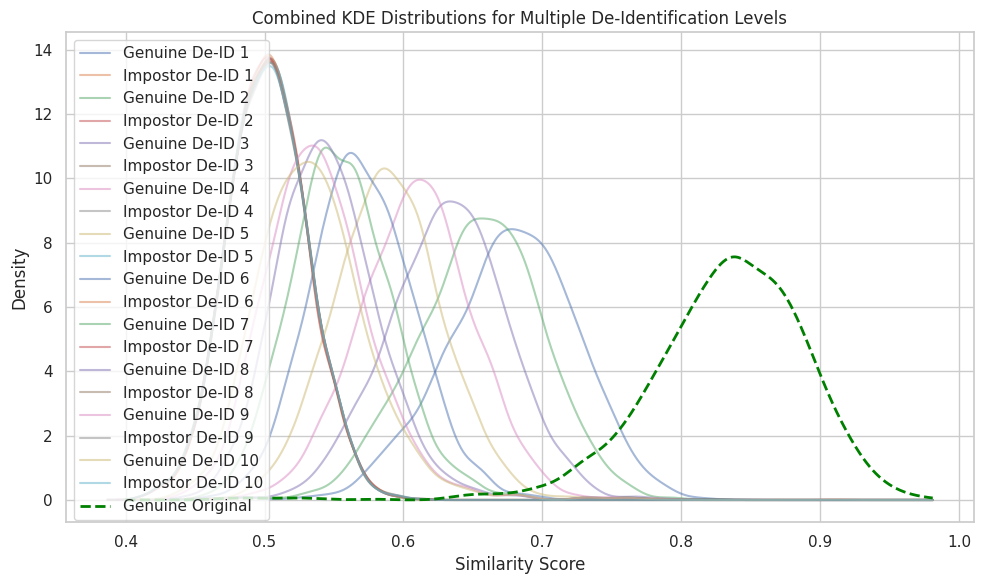

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import gaussian_kde

# List of CSV files to compare against the original
csv_files = [
    '../verification_scores_maskDDPG/LFW_benchmark_aligned_1_1_deid.csv',
    '../verification_scores_maskDDPG/LFW_benchmark_aligned_1_2_deid.csv',
    '../verification_scores_maskDDPG/LFW_benchmark_aligned_1_3_deid.csv',
    '../verification_scores_maskDDPG/LFW_benchmark_aligned_1_4_deid.csv',
    '../verification_scores_maskDDPG/LFW_benchmark_aligned_1_5_deid.csv',
    '../verification_scores_maskDDPG/LFW_benchmark_aligned_1_6_deid.csv',
    '../verification_scores_maskDDPG/LFW_benchmark_aligned_1_7_deid.csv',
    '../verification_scores_maskDDPG/LFW_benchmark_aligned_1_8_deid.csv',
    '../verification_scores_maskDDPG/LFW_benchmark_aligned_1_9_deid.csv',
    '../verification_scores_maskDDPG/LFW_benchmark_aligned_2_0_deid.csv'
]

# Original dataset
df_pairs_original = pd.read_csv('../data_with_similarity_final_original.csv')
df_pairs_original = df_pairs_original.dropna(subset=['Similarity'])
genuine_scores_original = df_pairs_original[df_pairs_original['IsGenuine']]['Similarity']

# Initialize Seaborn
sns.set(style="whitegrid")

# Prepare the figure
plt.figure(figsize=(10, 6))

# Loop through the CSV files and add KDE curves to the same plot
for idx, csv_file in enumerate(csv_files):
    # Load and clean the optimized data
    df_pairs_optimized = pd.read_csv(csv_file)
    df_pairs_optimized = df_pairs_optimized.dropna(subset=['Similarity'])
    
    # Split the data into genuine and impostor groups
    genuine_scores_deid = df_pairs_optimized[df_pairs_optimized['IsGenuine']]['Similarity']
    impostor_scores_deid = df_pairs_optimized[~df_pairs_optimized['IsGenuine']]['Similarity']
    
    # Kernel density estimation for genuine and impostor
    x_values = np.linspace(min(genuine_scores_deid.min(), genuine_scores_original.min()), 
                           max(genuine_scores_deid.max(), genuine_scores_original.max()), 1000)
    genuine_kde_deid = gaussian_kde(genuine_scores_deid)(x_values)
    impostor_kde_deid = gaussian_kde(impostor_scores_deid)(x_values)
    
    # Plot Genuine and Impostor curves with Seaborn lineplot for smooth shading
    sns.lineplot(x=x_values, y=genuine_kde_deid, label=f"Genuine De-ID {idx+1}", alpha=0.5)
    sns.lineplot(x=x_values, y=impostor_kde_deid, label=f"Impostor De-ID {idx+1}", alpha=0.5)

# Add the original genuine curve as a reference
genuine_kde_original = gaussian_kde(genuine_scores_original)(x_values)
sns.lineplot(x=x_values, y=genuine_kde_original, color='green', linestyle='--', label="Genuine Original", linewidth=2)

# Add labels and title
plt.title("Combined KDE Distributions for Multiple De-Identification Levels")
plt.xlabel("Similarity Score")
plt.ylabel("Density")
plt.legend()
plt.tight_layout()
plt.show()

